# Lab 3 - Perceptron & Gradient Descent

In this lab, we will discuss the Perceptron model, which can be trained using the Gradient Descent algorithm.

Specifically, we will cover the following topics:

1. Perceptron & Decision boundary
2. Perceptron & Gradient Descent
3. Mini-batch Stochastic Gradient Descent
4. Limitations

# Perceptron Model

The **Perceptron** is one of the simplest types of artificial neural networks, primarily used for binary classification tasks. It is a linear classifier that makes predictions based on a linear combination of input features.

- **Input Layer**: Receives the feature vector $\mathbf{x} = (x_1, x_2, \ldots, x_n)$
- **Labels**: with labels $y \in \{-1, 1\}$

The output of the Perceptron is calculated as:

$$
\hat{y} = \text{sign}(\mathbf{w}^T \mathbf{x} + b)
$$

- **Weights**: Each input $x_i$ is associated with a weight $w_i$.
- **Bias**: A constant value added to the weighted sum of inputs.


### Generate some data

We start by generating some linear separate data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)

In [2]:
mean = [0, 0]
covariance = [[1,0],
              [0,1]]
n_samples = 50

x = np.random.multivariate_normal(mean, covariance, n_samples)
y = np.random.choice(2, size=n_samples)
y[y==0]=-1
x[y ==-1 ]+=5

In [3]:
type(x)

numpy.ndarray

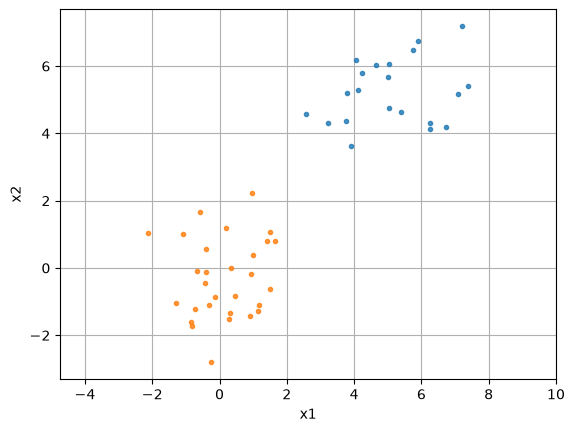

In [4]:
plt.figure()
plt.plot(x[y==-1,0], x[y==-1,1], '.', alpha=0.8)
plt.plot(x[y==1,0], x[y==1,1], '.', alpha=0.8)
plt.axis('equal')
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.show()

In [5]:
y

array([ 1,  1,  1, -1, -1,  1,  1,  1, -1,  1, -1, -1, -1,  1,  1,  1, -1,
        1, -1, -1,  1,  1,  1, -1,  1,  1, -1, -1, -1,  1, -1,  1,  1, -1,
       -1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1,  1,  1, -1, -1, -1])

In [6]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
standard_scaler = StandardScaler().fit(x)

x = standard_scaler.transform(x)
# sklearn return a numpy so we can convert back to pandas

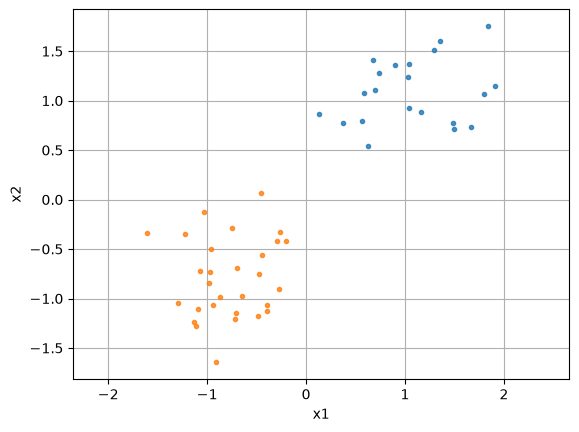

In [7]:
plt.figure()
plt.plot(x[y==-1,0], x[y==-1,1], '.', alpha=0.8)
plt.plot(x[y==1,0], x[y==1,1], '.', alpha=0.8)
plt.axis('equal')
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.show()

## Perceptron Decision Boundary

The perceptron is a linear model, which means it has a linear decision boundary that separates the classes.



.
<img src="../figures_set2/bd.png" alt="Decision Boundary" width="800" height="600">
.

## Decision Boundary for 2D Data

The decision boundary is defined by the equation:

$$
\mathbf{w}^T \mathbf{x} + b = 0
$$

This equation represents a hyperplane in the feature space as we see before.


For 2D data, the decision boundary is simply a line that we can visualize by rearranging the equation to solve for one of the variables, typically \( x_2 \):

$$
x_2 = -\frac{w_1}{w_2} x_1 - \frac{b}{w_2}
$$

where $w_1$ and $w_2$ are the components of the weight vector $\mathbf{w}$.  
The slope of the line is determined by the ratio $-\frac{w_1}{w_2}$, and the intercept is given by $-\frac{b}{w_2}$.

We can now plot the decision boundary of our model along with the data points to see how well it separates the classes.

In [8]:
w = np.array([2, 2])
b = np.array([-3])

In [9]:
x1_values = np.linspace(-5, 15, 100)

def get_decision_boundary(w, b, x1):
    x2_values = - (w[0] / w[1]) * x1 - (b / w[1])
    return x2_values

x2_values = get_decision_boundary(w=w, b=b, x1=x1_values)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


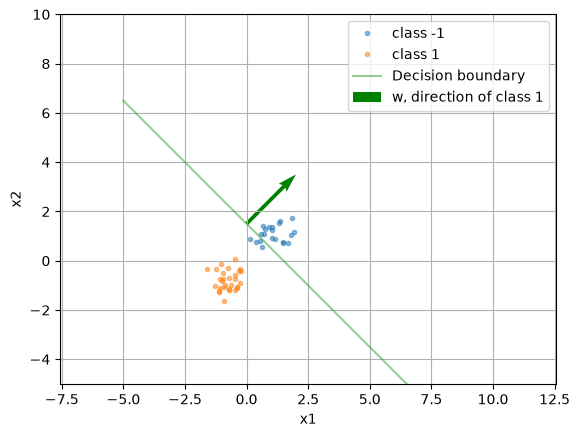

In [10]:
plt.figure()
plt.plot(x[y==-1 ,0], x[y==-1,1], '.', alpha=0.5, label = "class -1")
plt.plot(x[y==1, 0],  x[y==1,1], '.', alpha=0.5, label = "class 1")
plt.plot(x1_values, x2_values, alpha=0.5, label = "Decision boundary")
# Plot the weight vector, w, that is perpendicular to the decision boundary
x1_w = 0
x2_w = get_decision_boundary(w=w, b=b, x1=0)
plt.quiver(x1_w, x2_w, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='g', label="w, direction of class 1")
plt.axis('equal')
plt.ylim(-5,10)
plt.xlim(-5,10)
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid()
plt.show()

In [11]:
data_x = x
data_y = y

## Q1. Prediction

The output of the Perceptron is calculated as:

$$
\hat{y} = \text{sign}(\mathbf{w}^T \mathbf{x} + b) =  \text{sign}\left(\sum_{i=1}^{n} w_i x_i + b\right)
$$

At first you are ask to fill the predict method in order to make prediction with fixed weights.

In [12]:
class perceptron(object):
    def __init__(self,n_features,rs=42):
        np.random.seed(rs)
        self.w = np.array([2, 2])
        self.b = np.array([-3])
        
    def predict(self,x):
        y_hat = np.sign(np.sum(w * x,axis=1) + self.b)
        return y_hat

In [13]:
model = perceptron(n_features=2)
x_test = np.array([[5, 0],
                   [0, -5]])
model.predict(x_test)

array([ 1, -1])

# Learning Algorithm

The perceptron learning algorithm can be interpreted as stochastic subgradient descent on the perceptron loss.

Below, we review some common variants of gradient descent.

## **Gradient Descent Variants**

Gradient Descent minimizes a loss function $L(w; x, y)$ by updating model parameters $w$ in the direction opposite to the gradient.

---

### **1. Stochastic Gradient Descent (SGD)**  
Uses **one sample** per update — fast but noisy.

**Algorithm**
1. Initialize $w_0$
2. For each iteration $t = 1, \dots, T$:
   - Sample one $(x_i, y_i)$
   - Compute $g_t = \nabla_w L(w_t; x_i, y_i)$
   - Update $w_{t+1} = w_t - \eta g_t$
3. Return $w_T$

---

### **2. Mini-Batch Gradient Descent**  
Uses a **small batch** of samples — balances speed and stability.

**Algorithm**
1. Initialize $w_0$
2. For each iteration $t = 1, \dots, T$:
   - Sample batch $B_t = \{(x_i, y_i)\}_{i=1}^m$
   - Compute $g_t = \frac{1}{m} \sum_{(x_i, y_i) \in B_t} \nabla_w L(w_t; x_i, y_i)$
   - Update $w_{t+1} = w_t - \eta g_t$
3. Return $w_T$

---

### **3. Full-Batch Gradient Descent**  
Uses **all samples** each update — stable but slow for large datasets.

**Algorithm**
1. Initialize $w_0$
2. For each iteration $t = 1, \dots, T$:
   - Compute $g_t = \frac{1}{N} \sum_{i=1}^N \nabla_w L(w_t; x_i, y_i)$
   - Update $w_{t+1} = w_t - \eta g_t$
3. Return $w_T$


## Learning Algorithm for the Perceptron

The perceptron learns by adjusting its weights and bias when it makes an incorrect prediction.

For labels $y_i \in \{-1,+1\}$, if $y_i \neq \hat{y}_i$, we update the weights and bias as follows:

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta y_i \mathbf{x}_i
$$

$$
b \leftarrow b + \eta y_i
$$

where:

- $\eta > 0$ is the learning rate,
- $\mathbf{x}_i$ is the feature vector of example $i$,
- $y_i$ is the true label,
- $\hat{y}_i$ is the predicted label,
- $b$ is the bias.

#### Note

Gradient descent updates the model parameters to minimize a loss function.

For labels $y \in \{-1,+1\}$, the perceptron algorithm can be interpreted as stochastic subgradient descent on the **perceptron loss**:

$$
L(w,b;x,y)
=
-y(w^\top x+b)\,
\mathbb{I}\{y(w^\top x+b)<0\}.
$$

Equivalently, this can be written as:

$$
L(w,b;x,y)
=
\max\{0,-y(w^\top x+b)\}.
$$

The loss is zero when the signed margin is nonnegative and positive when the example is misclassified.

At zero margin, the loss is not differentiable.  
Choosing the subgradients for $w$ and $b$ gives the standard perceptron updates.

## Q2. Training

Implement the training method for the perceptron using labels $y_i \in \{-1,+1\}$.

For each training example $(\mathbf{x}_i, y_i)$:

1. Compute the prediction $\hat{y}_i$.
2. If $\hat{y}_i \neq y_i$, update the weights and bias:

   $$
   \mathbf{w} \leftarrow \mathbf{w} + \eta y_i \mathbf{x}_i
   $$

   $$
   b \leftarrow b + \eta y_i
   $$

   Otherwise, leave the weights and bias unchanged.

Here, $\eta > 0$ is the learning rate.

Your training method should support multiple passes through the training dataset.  
One complete pass through the dataset is called an **epoch**.

In [14]:
import sklearn
class perceptron(object):
    def __init__(self, n_features, rs):
        self.rs =rs
        np.random.seed(rs)
        self.w = np.random.uniform(size=n_features)
        self.b = np.random.uniform(size=1)
        self.w_history = [self.w]
        self.b_history = [self.b]
        self.x_history = []
        self.y_hat_history = []
        self.y_history = []
        
    def predict(self,x):
        y_hat = np.sign(np.sum(self.w * x,axis=1) + self.b)
        return y_hat
    
    def save_history(self, x, y_hat, y):
        self.w_history.append(self.w)
        self.b_history.append(self.b)
        self.x_history.append(x)
        self.y_hat_history.append(y_hat)
        self.y_history.append(y)
        
    def fit(self, data_x, data_y, lr,epochs):
        # for several epochs
        for epoch in range(epochs):
            
            # after each epoch
            data = sklearn.utils.shuffle(data_x, data_y, random_state=self.rs)
            random_x, random_y = data
            for x, y in zip(random_x, random_y):
                y_hat = self.predict([x])
                
                if y_hat == y:
                    continue # we dont have to update the weights
                else:
                    # now we update the weights
                    self.w = self.w + lr * y * x
                    self.b = self.b + lr * y * 1
                self.save_history(x,y_hat,y)

In [15]:
model = perceptron(n_features=2, rs=1234)

In [16]:
model.fit(data_x= x,data_y = y.reshape(-1,1), lr = 0.05, epochs=10)

In [17]:
model.w_history

[array([0.19151945, 0.62210877]),
 array([0.11134814, 0.60522254]),
 array([0.09157979, 0.54910442]),
 array([0.00179321, 0.49584989]),
 array([-0.02246112,  0.43698838]),
 array([-0.11444025,  0.34934387]),
 array([-0.18907348,  0.31362458]),
 array([-0.2473473 ,  0.26961427]),
 array([-0.29867248,  0.20745284]),
 array([-0.36355195,  0.13164473]),
 array([-0.41537237,  0.0630028 ]),
 array([-0.44663129,  0.03573043]),
 array([-0.45312396, -0.00743412]),
 array([-0.45961664, -0.05059867])]

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


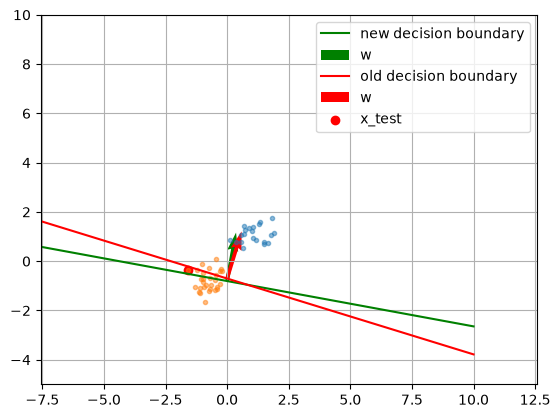

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


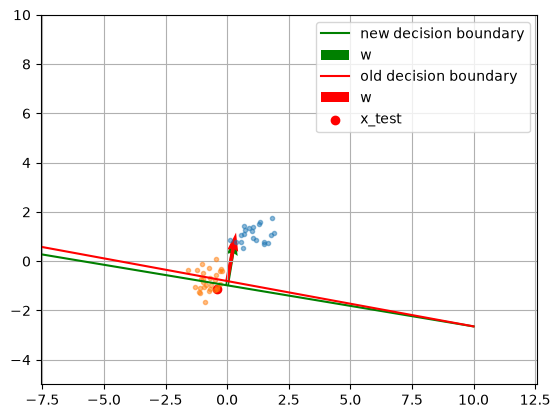

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


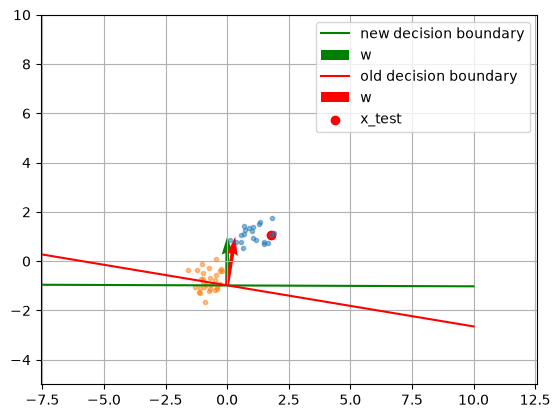

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


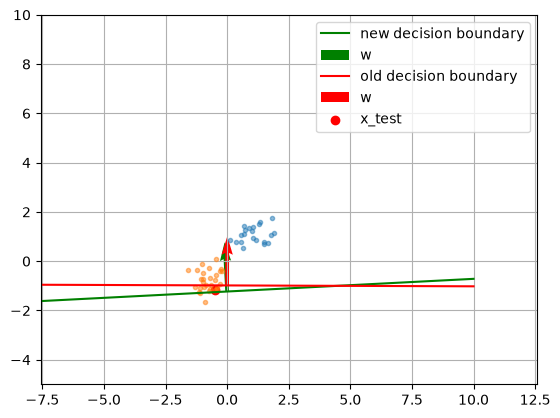

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


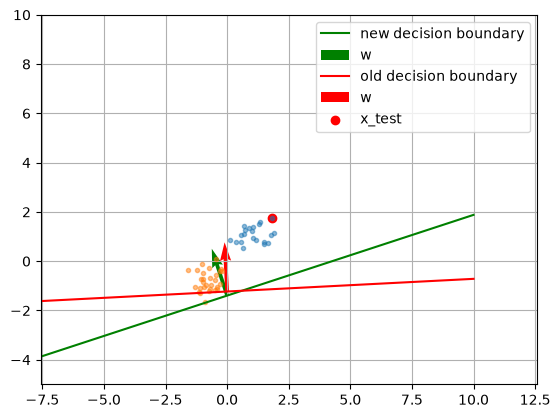

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


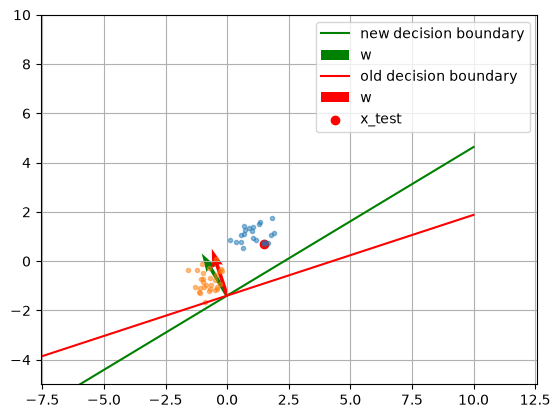

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


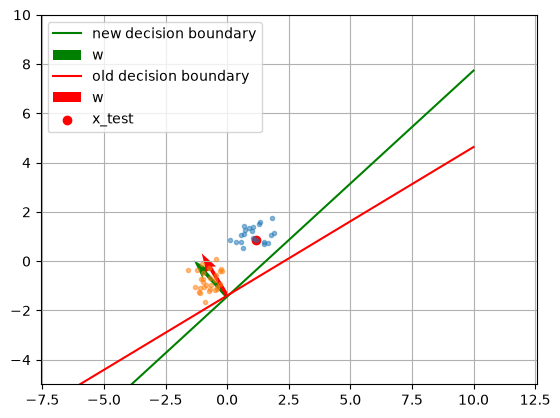

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


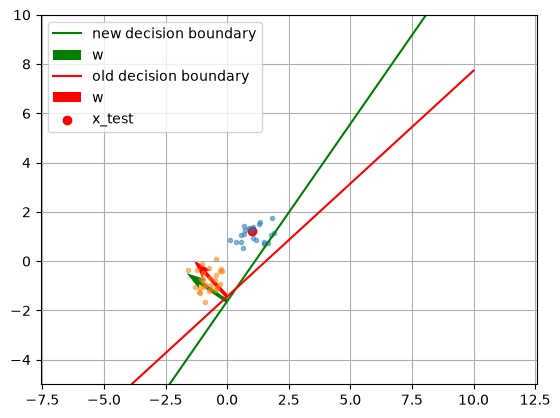

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


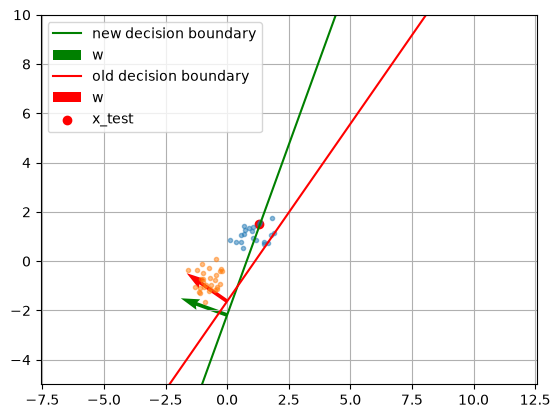

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


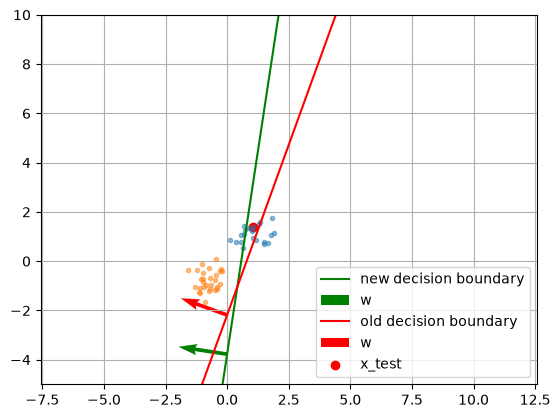

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


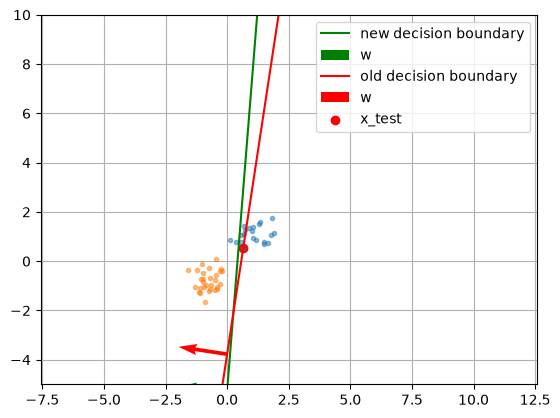

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


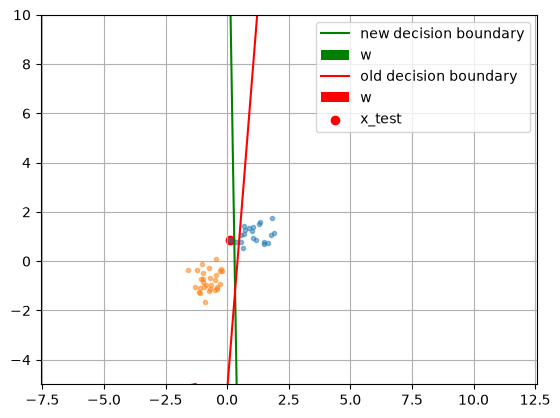

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


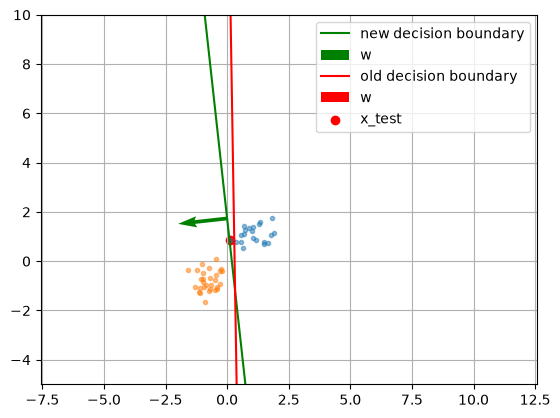

In [18]:
x1_values = np.linspace(-10, 10, 100)
for i in range(len(model.w_history)-1):
    plt.figure()
    plt.plot(x[y==-1,0], x[y==-1,1], '.', alpha=0.5)
    plt.plot(x[y==1,0], x[y==1,1], '.', alpha=0.5)
    # Calculate corresponding x2 values using the decision boundary equation

    w = model.w_history[i+1]
    b = model.b_history[i+1]
    norm = np.linalg.norm(w)
    x2_values = get_decision_boundary(w=w, b=b, x1=x1_values)
    plt.plot(x1_values, x2_values, label = f"new decision boundary", color= "g")
    x1_w = 0
    x2_w = get_decision_boundary(w=w, b=b, x1=0)
    w= w/norm
    plt.quiver(x1_w, x2_w, w[0], w[1], scale_units='xy',angles='xy', scale=1/2, color='g', label="w")
    plt.axis('equal')
    
    w = model.w_history[i]
    b = model.b_history[i]
    norm = np.linalg.norm(w)
    x2_values = get_decision_boundary(w=w, b=b, x1=x1_values)
    plt.plot(x1_values, x2_values, label = f"old decision boundary",color="r")
    x1_w = 0
    x2_w = get_decision_boundary(w=w, b=b, x1=0)
    w= w/norm
    plt.quiver(x1_w, x2_w, w[0], w[1], scale_units='xy',angles='xy', scale=1/2, color='r', label="w")
    plt.axis('equal')
    
    x_test = model.x_history[i]
    plt.scatter(x_test[0],x_test[1],color = "red", label = "x_test")
    plt.axis('equal')

    plt.ylim(-5,10)
    plt.xlim(-5,10)
    plt.legend()
    plt.grid()
    plt.show()

In general, in the case of linearly separable classes, the training will stop after a finite number of updates.

## Limitations

Now that we have defined the model and its training algorithm, we can examine some of the perceptron's limitations.

The **perceptron convergence theorem** states that, if the training data are linearly separable, the standard perceptron algorithm finds a separating decision boundary after a finite number of updates. This boundary correctly classifies all training examples.

However, the perceptron uses a linear decision boundary, so it cannot perfectly classify data that are not linearly separable in the given feature space.   
In this case, the algorithm may continue updating indefinitely.

**What can we do when the data cannot be separated by a straight line?**

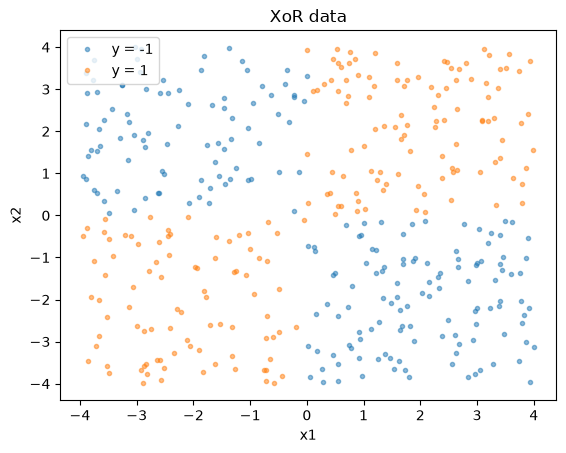

In [19]:
import numpy as np
import matplotlib.pyplot as plt

x = np.random.uniform(low=-4, high=4, size=(400,2))
y = np.bitwise_xor(np.sign(x[:,0]).astype(int),np.sign(x[:,1]).astype(int))
y[y==0] = 1 
y[y==-2] = - 1 
plt.figure()
plt.plot(x[y==-1,0], x[y==-1,1], '.', alpha=0.5, label = "y = -1")
plt.plot(x[y==1,0], x[y==1,1], '.', alpha=0.5, label = "y = 1")
plt.title("XoR data")
plt.ylabel("x2")
plt.xlabel("x1")
plt.legend()
plt.show()

## Q3. Training on a Dataset That Is Not Linearly Separable

1. Train your perceptron on the new dataset.
2. Visualize the resulting decision boundary.
3. Compute and report your model's classification accuracy on the training set.

In [21]:
# Initialise and train your model again.
from sklearn.datasets import load_digits
from sklearn.linear_model import Perceptron

perceptron_sklearn = Perceptron(eta0=0.01,  # learning rate
                                max_iter=10 # epochs
                               )
perceptron_sklearn.fit(x, y)

,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",10
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",0.01
,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


In [22]:
# Lets take the weights
w = perceptron_sklearn.coef_[0]
b = perceptron_sklearn.intercept_[0]

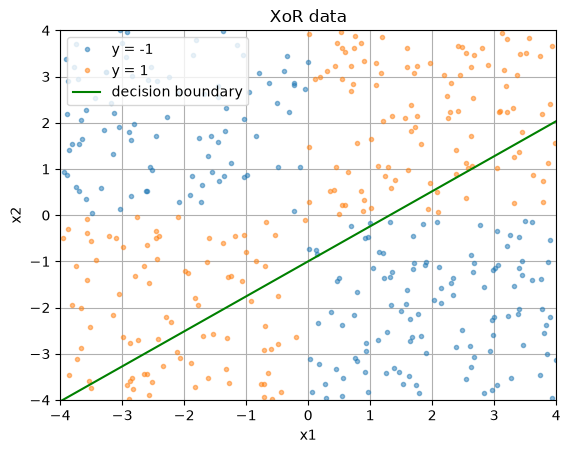

In [23]:
plt.figure()
plt.plot(x[y==-1,0], x[y==-1,1], '.', alpha=0.5, label = "y = -1")
plt.plot(x[y==1,0], x[y==1,1], '.', alpha=0.5, label = "y = 1")

x2_values = get_decision_boundary(w=w, b=b, x1=x1_values)
plt.plot(x1_values, x2_values, label = f"decision boundary", color= "g")

plt.title("XoR data")
plt.ylabel("x2")
plt.xlabel("x1")
plt.ylim(-4,4)
plt.xlim(-4,4)
plt.grid()
plt.legend()
plt.show()

In [28]:
# accuracy
accuracy = perceptron_sklearn.score(x,y)
accuracy

0.6475

## Q4. Comparing with KNN

KNN can represent nonlinear decision boundaries, making it suitable for this dataset.

1. Fit a KNN classifier on the same dataset using approximately 10 neighbours (e.g., `n_neighbors=10`).
2. Compute its classification accuracy the same way you did with the perceptron.
3. What do you observe?

You can use `KNeighborsClassifier` from `sklearn.neighbors`.

Complete your code below:

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=10) # just for demostration that knn works
knn.fit(x, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[-1, 1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [27]:
from sklearn.metrics import accuracy_score

# accuracy
y_pred = knn.predict(x)
knn_acc = accuracy_score(y_true=y,
                         y_pred= y_pred)
knn_acc

0.98

#### Applications

Despite its limitations, the perceptron provides a foundation for understanding more complex machine learning models.

In later labs, we will explore techniques for handling data that are not linearly separable and see how perceptron serve as building blocks of neural networks.